In [1]:
import sys
!{sys.executable} -m pip install pandas openpyxl numpy matplotlib scikit-learn nltk textblob wordcloud


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import pandas as pd
import numpy as np

df = pd.read_excel("TicketsHD.xlsx")

print("Shape:", df.shape)

Shape: (16595, 21)


In [21]:
import pandas as pd
import numpy as np

df = pd.read_excel("TicketsHD.xlsx")

print("Shape (filas, columnas):", df.shape)

print("\nColumnas (con índice):")
for i, c in enumerate(df.columns):
    print(f"{i:02d} - {c}")

print("\nTipos de dato (resumen):")
display(df.dtypes.value_counts())

print("\nEjemplo de datos (5 filas):")
display(df.head(5))

print("\nNulos (top 25):")
nulls = df.isna().sum().sort_values(ascending=False)
display(nulls.head(25))

print("\nCardinalidad (cuántos valores únicos) - top 25:")
nunq = df.nunique(dropna=True).sort_values(ascending=False)
display(nunq.head(25))

Shape (filas, columnas): (16595, 21)

Columnas (con índice):
00 - TICKET_ID
01 - TICKET_ASUNTO
02 - TICKET_PETICIONARIO
03 - TICKET_DESCRIPCION
04 - TICKET_CORREO_PETICIONARIO
05 - TICKET_ADJUNTO
06 - CREACION
07 - ACTUALIZACION
08 - TICKET_TIPO
09 - GRUPO
10 - ORIGEN
11 - TICKET_ESTADO
12 - PRIORIDAD
13 - DESCRIPCION_RESPUESTA
14 - ADJUNTO_RESPUESTA
15 - AGENTE
16 - FECHA_RESPUESTA
17 - TELEFONO_PETICIONARIO
18 - ID_TIPO_ASUNTO
19 - CEDULA
20 - LOTE

Tipos de dato (resumen):


str        18
int64       2
float64     1
Name: count, dtype: int64


Ejemplo de datos (5 filas):


,TICKET_ID,TICKET_ASUNTO,TICKET_PETICIONARIO,TICKET_DESCRIPCION,TICKET_CORREO_PETICIONARIO,TICKET_ADJUNTO,CREACION,ACTUALIZACION,TICKET_TIPO,GRUPO,...,TICKET_ESTADO,PRIORIDAD,DESCRIPCION_RESPUESTA,ADJUNTO_RESPUESTA,AGENTE,FECHA_RESPUESTA,TELEFONO_PETICIONARIO,ID_TIPO_ASUNTO,CEDULA,LOTE
0,37,RECUPERACIÓN USUARIO Y CONTRASEÑA,Juan Miguel Cujia Fernández,No puedo ingresar a la plataforma.,jcujia14@gmail.com,NaN,2024-08-07 13:16:00,2024-08-07 13:16:00,Ticket Normal,Soporte,...,Resuelto,Media,Cordial saludo Sr. Juan Miguel Cujia Fernández...,NaN,Felipe Bermudez,2024-08-07 10:07:46,3.184304e+09,4,1065628763,No Aplica
1,38,RECUPERACIÓN USUARIO Y CONTRASEÑA,Juan Miguel Cujia Fernández,No puedo ingresar a la plataforma.,jcujia14@gmail.com,NaN,2024-08-07 13:16:02,2024-08-07 13:16:02,Ticket Normal,Soporte,...,Resuelto,Media,Cordial saludo Sr. Juan Miguel Cujia Fernández...,NaN,Felipe Bermudez,2024-08-07 10:10:13,3.184304e+09,4,1065628763,No Aplica
2,39,RECUPERACIÓN USUARIO Y CONTRASEÑA,Ana Mosquera Lozano,No recuerdo mi contraseña,armosqueral@yahoo.es,NaN,2024-08-07 13:23:04,2024-08-07 13:23:04,Ticket Normal,Soporte,...,Resuelto,Media,"Cordial saludo Sr. Ana Mosquera Lozano, en ref...",NaN,Felipe Bermudez,2024-08-07 10:04:28,NaN,4,43901913,No Aplica
3,40,INFORMACIÓN DE CONVOCATORIO,Yurleidis esther beltran herrera,Buen dia me enviaron este link,yurleidis_2413@hotmail.com,NaN,2024-08-07 13:33:52,2024-08-07 13:33:52,Ticket Normal,Soporte,...,Resuelto,Media,Cordial saludo Sra Yurleidis Esther Beltran He...,NaN,Felipe Bermudez,2024-08-07 10:13:03,3.013960e+09,1,1046692575,Región 6
4,41,INFORMACIÓN DE CONVOCATORIO,Yurleidis esther beltran herrera,Buen dia me enviaron este link,yurleidis_2413@hotmail.com,NaN,2024-08-07 13:33:54,2024-08-07 13:33:54,Ticket Normal,Soporte,...,Resuelto,Media,Cordial saludo Sra yurleidis Esther Beltran He...,NaN,Felipe Bermudez,2024-08-07 10:15:01,3.013960e+09,1,1046692575,Región 6



Nulos (top 25):


TICKET_ADJUNTO                12545
ADJUNTO_RESPUESTA             11827
TELEFONO_PETICIONARIO            51
TICKET_DESCRIPCION               10
TICKET_ESTADO                     9
DESCRIPCION_RESPUESTA             9
AGENTE                            9
LOTE                              9
FECHA_RESPUESTA                   9
CEDULA                            4
TICKET_CORREO_PETICIONARIO        2
TICKET_ID                         0
TICKET_PETICIONARIO               0
TICKET_ASUNTO                     0
ORIGEN                            0
PRIORIDAD                         0
TICKET_TIPO                       0
CREACION                          0
ACTUALIZACION                     0
GRUPO                             0
ID_TIPO_ASUNTO                    0
dtype: int64


Cardinalidad (cuántos valores únicos) - top 25:


TICKET_ID                     16595
ACTUALIZACION                 16569
CREACION                      16568
FECHA_RESPUESTA               16566
DESCRIPCION_RESPUESTA         15426
TICKET_DESCRIPCION            15410
TICKET_PETICIONARIO           12772
TICKET_CORREO_PETICIONARIO    11227
TELEFONO_PETICIONARIO         10604
CEDULA                        10484
ADJUNTO_RESPUESTA              4768
TICKET_ADJUNTO                 4050
AGENTE                           33
TICKET_ASUNTO                    20
ID_TIPO_ASUNTO                   20
LOTE                             10
GRUPO                             8
TICKET_ESTADO                     3
PRIORIDAD                         3
ORIGEN                            2
TICKET_TIPO                       2
dtype: int64

In [22]:
# --- Convertir a formato datetime ---
df["CREACION"] = pd.to_datetime(df["CREACION"], errors="coerce")
df["FECHA_RESPUESTA"] = pd.to_datetime(df["FECHA_RESPUESTA"], errors="coerce")

# --- Calcular tiempo de resolución ---
df["TIEMPO_HORAS"] = (df["FECHA_RESPUESTA"] - df["CREACION"]).dt.total_seconds() / 3600
df["TIEMPO_DIAS"] = df["TIEMPO_HORAS"] / 24

# --- Verificar resultados ---
print("Estadísticas de tiempo (horas):")
display(df["TIEMPO_HORAS"].describe())

print("\nValores negativos (si existen):")
print((df["TIEMPO_HORAS"] < 0).sum())

print("\nValores nulos en tiempo:")
print(df["TIEMPO_HORAS"].isna().sum())

Estadísticas de tiempo (horas):


count    16586.000000
mean        79.346048
std        214.109792
min         -4.353889
25%         14.628056
50%         36.503750
75%         89.643750
max       8082.786667
Name: TIEMPO_HORAS, dtype: float64


Valores negativos (si existen):
13

Valores nulos en tiempo:
9


Promedio: 79.3 horas (~3.3 días)

Mediana: 36.5 horas (~1.5 días)

Máximo: 8082 horas (~336 días)

Valores negativos: 13

Nulos: 9

Interpretación inicial (importante)

La media es mucho mayor que la mediana → distribución sesgada (outliers fuertes).

Hay tickets que duraron casi 1 año.

Hay 13 registros con tiempo negativo → error de datos (respuesta antes de creación).

In [23]:
#Limpieza mínima obligatoria
# Copia limpia
df_clean = df.copy()

# Eliminar negativos
df_clean = df_clean[df_clean["TIEMPO_HORAS"] >= 0]

# Eliminar nulos
df_clean = df_clean.dropna(subset=["TIEMPO_HORAS"])

print("Nuevo tamaño:", df_clean.shape)

print("\nNueva media:", df_clean["TIEMPO_HORAS"].mean())
print("Nueva mediana:", df_clean["TIEMPO_HORAS"].median())

Nuevo tamaño: (16573, 23)

Nueva media: 79.41099646681015
Nueva mediana: 36.6025


In [24]:
# Redondear a horas enteras reales
df_clean["HORAS_24H"] = df_clean["TIEMPO_HORAS"].round(0)

# Días naturales enteros
df_clean["DIAS"] = (df_clean["HORAS_24H"] / 24).round(0)

print("Estadísticas en DÍAS:")
display(df_clean["DIAS"].describe())

print("\nEstadísticas en HORAS (24h reales):")
display(df_clean["HORAS_24H"].describe())

Estadísticas en DÍAS:


count    16573.000000
mean         3.362940
std          8.934322
min          0.000000
25%          1.000000
50%          2.000000
75%          4.000000
max        337.000000
Name: DIAS, dtype: float64


Estadísticas en HORAS (24h reales):


count    16573.000000
mean        79.406143
std        214.183462
min          0.000000
25%         15.000000
50%         37.000000
75%         90.000000
max       8083.000000
Name: HORAS_24H, dtype: float64

Interpretación ejecutiva
Tiempo de resolución (en días)
Promedio: 3.36 días
Mediana: 2 días
75% de los tickets: ≤ 4 días
Casos extremos: hasta 337 días 😳
--> Qué significa esto
La operación normal resuelve en 1–4 días.
La media es mayor que la mediana → existen casos muy largos que inflan el promedio.
Hay una cola larga fuerte (hasta 337 días).
Esto ya es hallazgo de gestión:
El problema no es la operación promedio, son los casos extremos.

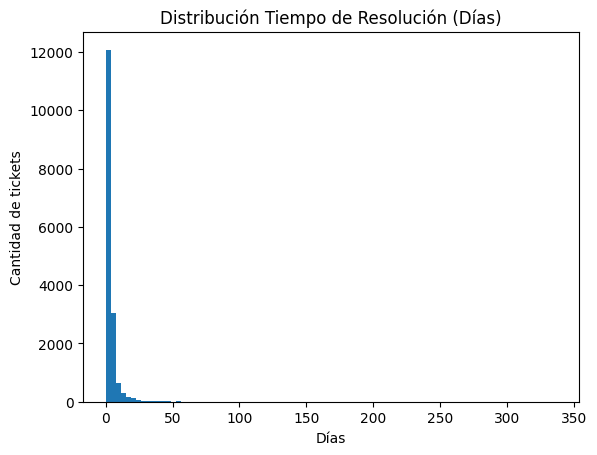

In [25]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df_clean["DIAS"], bins=90)
plt.title("Distribución Tiempo de Resolución (Días)")
plt.xlabel("Días")
plt.ylabel("Cantidad de tickets")
plt.show()

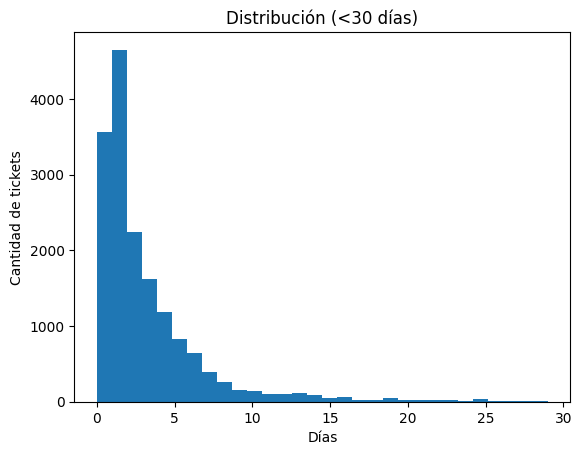

In [26]:
plt.figure()
plt.hist(df_clean[df_clean["DIAS"] < 30]["DIAS"], bins=30)
plt.title("Distribución (<30 días)")
plt.xlabel("Días")
plt.ylabel("Cantidad de tickets")
plt.show()

In [27]:
# Tiempo promedio por PRIORIDAD
print("Tiempo promedio por PRIORIDAD (días):")
display(
    df_clean.groupby("PRIORIDAD")["DIAS"]
    .mean()
    .sort_values(ascending=False)
)

# Tiempo promedio por GRUPO
print("\nTiempo promedio por GRUPO (días):")
display(
    df_clean.groupby("GRUPO")["DIAS"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Tiempo promedio por ORIGEN
print("\nTiempo promedio por ORIGEN (días):")
display(
    df_clean.groupby("ORIGEN")["DIAS"]
    .mean()
    .sort_values(ascending=False)
)

Tiempo promedio por PRIORIDAD (días):


PRIORIDAD
Alta     4.799320
Media    3.312113
Baja     0.100000
Name: DIAS, dtype: float64


Tiempo promedio por GRUPO (días):


GRUPO
Líder de Seguimiento     88.000000
EA - Mentores            37.000000
MAP - Ingles Técnico     28.519231
Desarrollo               12.083916
MAP - Pedagogía           6.941968
Coordinador Academico     6.666667
Soporte                   2.818750
PQRS                      2.000000
Name: DIAS, dtype: float64


Tiempo promedio por ORIGEN (días):


ORIGEN
Otro       3.413321
ChatBot    2.435597
Name: DIAS, dtype: float64

La operación técnica funciona.
El cuello de botella está en procesos administrativos / seguimiento.
Las prioridades altas no están siendo atendidas proporcionalmente.
Chatbot está ayudando.
Hallazgos críticos

--> El problema NO es Soporte.
El problema está en procesos de seguimiento y escalamiento.
Los grupos con tiempos extremos parecen ser:
Gestión administrativa
Seguimiento
Procesos académicos

In [28]:
df_clean["TEXTO_COMPLETO"] = (
    df_clean["TICKET_ASUNTO"].fillna("") + " " +
    df_clean["TICKET_DESCRIPCION"].fillna("")
)

print("Ejemplo de texto:")
print(df_clean["TEXTO_COMPLETO"].iloc[0])

Ejemplo de texto:
INFORMACIÓN DE INSCRIPCIÓN Quedo atento


In [29]:
import re
import nltk
from nltk.corpus import stopwords

# Descargar stopwords si es primera vez
nltk.download('stopwords')

stop_words = set(stopwords.words('spanish'))

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'\d+', '', texto)
    texto = re.sub(r'[^\w\s]', '', texto)
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stop_words and len(p) > 2]
    return " ".join(palabras)

df_clean["TEXTO_LIMPIO"] = df_clean["TEXTO_COMPLETO"].apply(limpiar_texto)

print("Texto limpio ejemplo:")
print(df_clean["TEXTO_LIMPIO"].iloc[0])

Texto limpio ejemplo:
información inscripción quedo atento


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\marce\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [30]:
from collections import Counter
import pandas as pd

# Unir todo el texto limpio
texto_total = " ".join(df_clean["TEXTO_LIMPIO"])

# Contar palabras
contador = Counter(texto_total.split())

# Convertir a DataFrame
df_palabras = pd.DataFrame(contador.items(), columns=["Palabra", "Frecuencia"])

# Ordenar
df_palabras = df_palabras.sort_values(by="Frecuencia", ascending=False).reset_index(drop=True)

# Mostrar Top 30
display(df_palabras.head(30))

,Palabra,Frecuencia
0,plataforma,9525
1,curso,7961
2,_xd_,6947
3,acceso,6494
4,información,4424
5,contraseña,4400
6,usuario,4060
7,ingresar,3485
8,correo,3481
9,inscripción,2880


Esto indica que la mayoría de tickets son:

Problemas de acceso / autenticación / plataforma / inscripción.

In [33]:
from collections import Counter

texto_total = " ".join(df_clean["TEXTO_LIMPIO"])
contador = Counter(texto_total.split())
top_30 = contador.most_common(30)

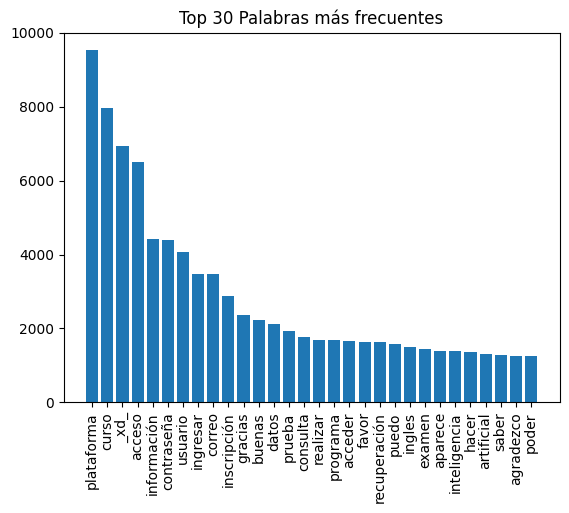

In [34]:
import matplotlib.pyplot as plt

palabras = [x[0] for x in top_30]
frecuencias = [x[1] for x in top_30]

plt.figure()
plt.bar(palabras, frecuencias)
plt.xticks(rotation=90)
plt.title("Top 30 Palabras más frecuentes")
plt.show()

In [35]:
# Separar dataset por velocidad
# Definir grupos
df_rapidos = df_clean[df_clean["DIAS"] <= 2]
df_lentos = df_clean[df_clean["DIAS"] > 7]

print("Tickets rápidos:", df_rapidos.shape[0])
print("Tickets lentos:", df_lentos.shape[0])

Tickets rápidos: 10458
Tickets lentos: 1445


In [36]:
# Palabras más frecuentes por grupo
from collections import Counter

def top_palabras(df_texto, n=20):
    texto = " ".join(df_texto["TEXTO_LIMPIO"])
    contador = Counter(texto.split())
    df_temp = pd.DataFrame(contador.items(), columns=["Palabra", "Frecuencia"])
    df_temp = df_temp.sort_values(by="Frecuencia", ascending=False).reset_index(drop=True)
    return df_temp.head(n)

print("Top palabras - Tickets RÁPIDOS")
display(top_palabras(df_rapidos, 20))

print("\nTop palabras - Tickets LENTOS")
display(top_palabras(df_lentos, 20))

Top palabras - Tickets RÁPIDOS


,Palabra,Frecuencia
0,plataforma,6158
1,curso,4748
2,_xd_,4378
3,acceso,4318
4,contraseña,3053
5,usuario,2807
6,información,2691
7,ingresar,2332
8,correo,2253
9,inscripción,1775



Top palabras - Tickets LENTOS


,Palabra,Frecuencia
0,curso,885
1,_xd_,749
2,plataforma,709
3,información,416
4,acceso,400
5,programa,266
6,contraseña,253
7,usuario,246
8,gracias,246
9,inscripción,240


con los tickets lentos sugiere:

Falta de priorización real.
Falta de SLA.
Acumulación en ciertos grupos.
Tickets olvidados.
Procesos sin cierre oportuno.

In [37]:
#Tiempo promedio por palabra específica
def tiempo_promedio_palabra(palabra):
    filtro = df_clean["TEXTO_LIMPIO"].str.contains(palabra, na=False)
    promedio = df_clean[filtro]["DIAS"].mean()
    cantidad = df_clean[filtro].shape[0]
    return palabra, cantidad, round(promedio, 2)

palabras_clave = ["contraseña", "acceso", "inscripción", "curso", "certificado", "inglés"]

resultados = [tiempo_promedio_palabra(p) for p in palabras_clave]

df_resultado = pd.DataFrame(resultados, columns=["Palabra", "Cantidad", "Promedio_dias"])
display(df_resultado)

,Palabra,Cantidad,Promedio_dias
0,contraseña,3030,2.50
1,acceso,5372,2.67
2,inscripción,2388,3.00
3,curso,5323,3.61
4,certificado,738,4.03
5,inglés,851,4.59


Rápidos  
Son operativos y probablemente automatizables.

Intermedios
Pueden requerir validaciones internas.

Más lentos
Aquí hay proceso manual.
Puede depender de validaciones académicas.
Puede implicar revisión humana.

In [38]:
# Análisis de Sentimiento
from textblob import TextBlob

def obtener_sentimiento(texto):
    return TextBlob(texto).sentiment.polarity

df_clean["SENTIMIENTO"] = df_clean["TEXTO_COMPLETO"].apply(obtener_sentimiento)

print("Resumen sentimiento:")
display(df_clean["SENTIMIENTO"].describe())

Resumen sentimiento:


count    16573.000000
mean        -0.041788
std          0.168373
min         -0.937500
25%          0.000000
50%          0.000000
75%          0.000000
max          0.900000
Name: SENTIMIENTO, dtype: float64

In [39]:
# clasificacion de sentimiento
def clasificar_sentimiento(valor):
    if valor > 0.1:
        return "Positivo"
    elif valor < -0.1:
        return "Negativo"
    else:
        return "Neutral"

df_clean["TIPO_SENTIMIENTO"] = df_clean["SENTIMIENTO"].apply(clasificar_sentimiento)

display(df_clean["TIPO_SENTIMIENTO"].value_counts())

TIPO_SENTIMIENTO
Neutral     15116
Negativo     1283
Positivo      174
Name: count, dtype: int64

In [40]:
print("Tiempo promedio por tipo de sentimiento:")
display(
    df_clean.groupby("TIPO_SENTIMIENTO")["DIAS"]
    .mean()
    .sort_values(ascending=False)
)

Tiempo promedio por tipo de sentimiento:


TIPO_SENTIMIENTO
Positivo    6.752874
Negativo    4.382697
Neutral     3.237364
Name: DIAS, dtype: float64

In [41]:
# Análisis por GRUPO
# Crear variable de demora crítica (>7 días)
df_clean["DEMORA_CRITICA"] = df_clean["DIAS"] > 7

resumen_grupo = df_clean.groupby("GRUPO").agg(
    Total_Tickets=("DIAS", "count"),
    Promedio_Dias=("DIAS", "mean"),
    Mediana_Dias=("DIAS", "median"),
    Porcentaje_Demora_Critica=("DEMORA_CRITICA", "mean")
).reset_index()

resumen_grupo["Porcentaje_Demora_Critica"] = (
    resumen_grupo["Porcentaje_Demora_Critica"] * 100
).round(2)

resumen_grupo = resumen_grupo.sort_values(by="Promedio_Dias", ascending=False)

display(resumen_grupo)

,GRUPO,Total_Tickets,Promedio_Dias,Mediana_Dias,Porcentaje_Demora_Critica
3,Líder de Seguimiento,1,88.000000,88.0,100.00
2,EA - Mentores,1,37.000000,37.0,100.00
4,MAP - Ingles Técnico,52,28.519231,6.0,38.46
1,Desarrollo,286,12.083916,6.0,46.85
5,MAP - Pedagogía,1189,6.941968,2.0,21.53
0,Coordinador Academico,3,6.666667,6.0,33.33
7,Soporte,15040,2.818750,1.0,6.86
6,PQRS,1,2.000000,2.0,0.00


In [42]:
#demoras críticas por GRUPO
# Filtrar solo tickets con demora crítica (>7 días)
df_criticos = df_clean[df_clean["DEMORA_CRITICA"] == True]

# Contar por grupo
pareto = df_criticos.groupby("GRUPO").size().reset_index(name="Cantidad_Criticos")

# Ordenar de mayor a menor
pareto = pareto.sort_values(by="Cantidad_Criticos", ascending=False)

# Calcular porcentaje acumulado
pareto["Porcentaje"] = (pareto["Cantidad_Criticos"] / pareto["Cantidad_Criticos"].sum() * 100).round(2)
pareto["Porcentaje_Acumulado"] = pareto["Porcentaje"].cumsum().round(2)

display(pareto)

,GRUPO,Cantidad_Criticos,Porcentaje,Porcentaje_Acumulado
6,Soporte,1032,71.42,71.42
5,MAP - Pedagogía,256,17.72,89.14
1,Desarrollo,134,9.27,98.41
4,MAP - Ingles Técnico,20,1.38,99.79
0,Coordinador Academico,1,0.07,99.86
2,EA - Mentores,1,0.07,99.93
3,Líder de Seguimiento,1,0.07,100.00


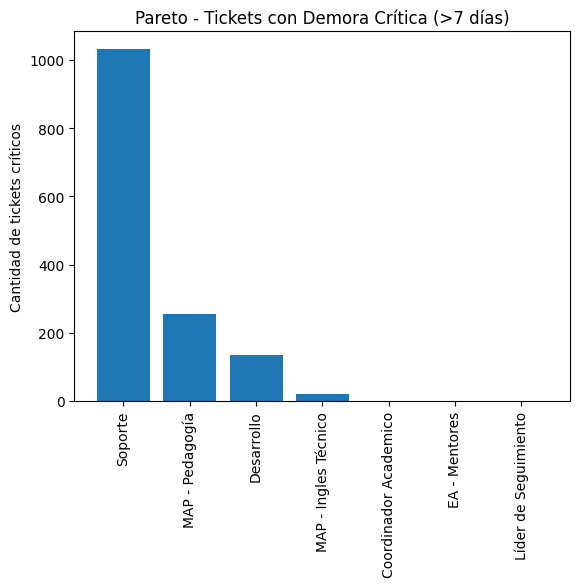

In [43]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(pareto["GRUPO"], pareto["Cantidad_Criticos"])
plt.xticks(rotation=90)

plt.title("Pareto - Tickets con Demora Crítica (>7 días)")
plt.ylabel("Cantidad de tickets críticos")

plt.show()

Soporte maneja el 90% del volumen total.

Incluso con 6.8% de demora
Eso produce la mayoría de críticos en número absoluto.
//Es efecto volumen

1. Heatmap PRIORIDAD vs GRUPO vs Demora
Alta prioridad en Soporte sí se atiende más rápido.
Desarrollo ignora prioridad.

2. Análisis temporal (mes a mes)
Las demoras están aumentando.
Hay estacionalidad.
Hay picos de carga.

In [44]:
# Crear columna de año-mes
df_clean["ANIO_MES"] = df_clean["CREACION"].dt.to_period("M")

# Ver ejemplo
display(df_clean[["CREACION", "ANIO_MES"]].head())

,CREACION,ANIO_MES
8,2024-08-07 13:44:36,2024-08
14,2024-08-07 08:59:52,2024-08
15,2024-08-07 08:59:54,2024-08
16,2024-08-07 09:10:32,2024-08
17,2024-08-07 09:12:27,2024-08


In [45]:
# Tickets por mes
tickets_mes = df_clean.groupby("ANIO_MES").size().reset_index(name="Cantidad_Tickets")

display(tickets_mes)

,ANIO_MES,Cantidad_Tickets
0,2024-08,2127
1,2024-09,1435
2,2024-10,1114
3,2024-11,1746
4,2024-12,522
5,2025-01,157
6,2025-02,1244
7,2025-03,520
8,2025-04,1224
9,2025-05,1086


In [46]:
#Promedio de días por mes
tiempo_mes = df_clean.groupby("ANIO_MES")["DIAS"].mean().reset_index()

display(tiempo_mes)

,ANIO_MES,DIAS
0,2024-08,1.314057
1,2024-09,3.720557
2,2024-10,3.962298
3,2024-11,3.761741
4,2024-12,2.323755
5,2025-01,6.490446
6,2025-02,4.190514
7,2025-03,6.971154
8,2025-04,2.802288
9,2025-05,3.447514


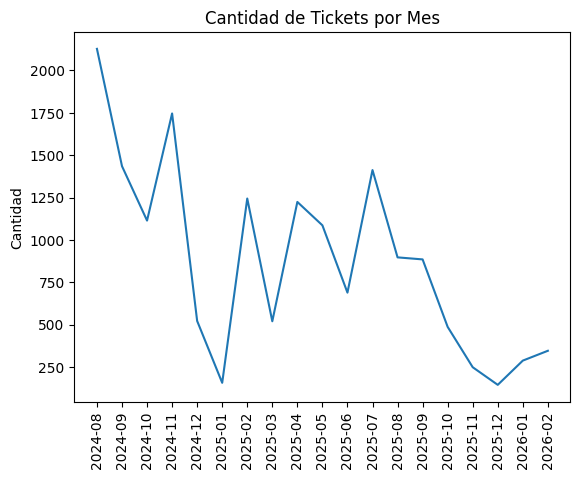

In [47]:
# grafica volumen de tickets por mes
import matplotlib.pyplot as plt

plt.figure()
plt.plot(tickets_mes["ANIO_MES"].astype(str), tickets_mes["Cantidad_Tickets"])
plt.xticks(rotation=90)
plt.title("Cantidad de Tickets por Mes")
plt.ylabel("Cantidad")
plt.show()

Inicio alto en 2024-08 (~2100)
Fuerte caída en 2025-01 (~150)
Luego rebote fuerte
Pico importante en 2025-07 (~1400)
Después caída progresiva hacia finales de 2025
2026 empieza bajo

**Interpretación posible**

Hay estacionalidad clara.
Enero 2025 parece periodo muerto (vacaciones académicas).
Julio 2025 parece pico académico (inscripciones, inicios).
Finales 2025 baja fuerte volumen.
Esto parece ciclo académico claro.

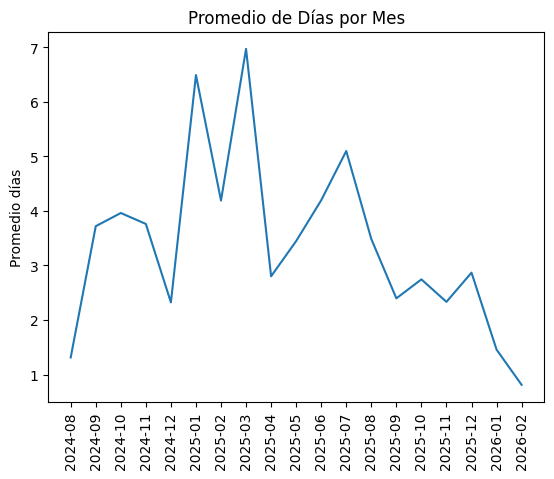

In [48]:
# grafica promedio de días por mes
plt.figure()
plt.plot(tiempo_mes["ANIO_MES"].astype(str), tiempo_mes["DIAS"])
plt.xticks(rotation=90)
plt.title("Promedio de Días por Mes")
plt.ylabel("Promedio días")
plt.show()

Picos fuertes en:
2025-01 (~6.5 días)
2025-03 (~7 días)
2025-07 (~5 días)
Después mejora sostenida.
Final 2025 e inicio 2026 baja hasta ~1 día.

*No parece un problema de eficiencia fija.*
Parece un problema de capacidad vs demanda.
Cuando sube volumen:
→ suben tiempos.
Cuando baja volumen:
→ mejora eficiencia.

In [49]:
#Correlación carga vs tiempo
# Unir tablas
df_mes = tickets_mes.merge(tiempo_mes, on="ANIO_MES")

# Calcular correlación
correlacion = df_mes["Cantidad_Tickets"].corr(df_mes["DIAS"])

print("Correlación entre volumen y promedio de días:", round(correlacion, 3))

display(df_mes)

Correlación entre volumen y promedio de días: -0.026


,ANIO_MES,Cantidad_Tickets,DIAS
0,2024-08,2127,1.314057
1,2024-09,1435,3.720557
2,2024-10,1114,3.962298
3,2024-11,1746,3.761741
4,2024-12,522,2.323755
5,2025-01,157,6.490446
6,2025-02,1244,4.190514
7,2025-03,520,6.971154
8,2025-04,1224,2.802288
9,2025-05,1086,3.447514


Los dias equivalen al tiempo de creacion y respuesta promedio del ticket 
Puede ser:
    Cambios de equipo
    Transición de proceso
    Backlog acumulado
    Cambio de sistema
    Falta de SLA formal
    Reasignaciones internas

**MODELO**

In [50]:
# Crear variable objetivo
# Crear variable binaria
df_clean["RIESGO_OPERATIVO"] = (df_clean["DIAS"] > 5).astype(int)

print("Distribución de la variable objetivo:")
display(df_clean["RIESGO_OPERATIVO"].value_counts())

print("\nPorcentaje:")
display(df_clean["RIESGO_OPERATIVO"].value_counts(normalize=True) * 100)

Distribución de la variable objetivo:


RIESGO_OPERATIVO
0    14096
1     2477
Name: count, dtype: int64


Porcentaje:


RIESGO_OPERATIVO
0    85.054003
1    14.945997
Name: proportion, dtype: float64

TEXTO_LIMPIO → TF-IDF

PRIORIDAD → One-hot

GRUPO → One-hot

ORIGEN → One-hot

Modelo inicial recomendado:
    Logistic Regression (interpretable y robusto)

In [51]:
# Preparar datos
from sklearn.model_selection import train_test_split

# Variables
X_texto = df_clean["TEXTO_LIMPIO"]
X_cat = df_clean[["PRIORIDAD", "GRUPO", "ORIGEN"]]
y = df_clean["RIESGO_OPERATIVO"]

# Split
X_text_train, X_text_test, X_cat_train, X_cat_test, y_train, y_test = train_test_split(
    X_texto, X_cat, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", y_train.shape[0])
print("Test size:", y_test.shape[0])

Train size: 13258
Test size: 3315


In [52]:
#Vectorizar texto + variables categóricas
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack

# TF-IDF
vectorizer = TfidfVectorizer(max_features=3000)
X_text_train_tfidf = vectorizer.fit_transform(X_text_train)
X_text_test_tfidf = vectorizer.transform(X_text_test)

# One-hot categóricas
encoder = OneHotEncoder(handle_unknown="ignore")
X_cat_train_enc = encoder.fit_transform(X_cat_train)
X_cat_test_enc = encoder.transform(X_cat_test)

# Combinar texto + categóricas
X_train = hstack([X_text_train_tfidf, X_cat_train_enc])
X_test = hstack([X_text_test_tfidf, X_cat_test_enc])

print("Dimensión final entrenamiento:", X_train.shape)

Dimensión final entrenamiento: (13258, 3013)


13,258 registros de entrenamiento

3,315 de prueba

3,013 features (texto + categóricas)

In [54]:
#Entrenar Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Modelo
modelo = LogisticRegression(class_weight="balanced", max_iter=1000)

# Entrenar
modelo.fit(X_train, y_train)

# Predicción
y_pred = modelo.predict(X_test)

# Resultados
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.88      0.73      0.80      2820
           1       0.22      0.43      0.29       495

    accuracy                           0.69      3315
   macro avg       0.55      0.58      0.55      3315
weighted avg       0.78      0.69      0.72      3315


Matriz de confusión:
[[2069  751]
 [ 282  213]]


Clase 1 (RIESGO >5 días)
    Recall: 0.43
    Precision: 0.22
    F1-score: 0.29

Matriz de confusión
    Verdaderos negativos: 2069
    Falsos positivos: 751
    Falsos negativos: 282
    Verdaderos positivos: 213
✔ Detecta 43% de los tickets de riesgo
❌ Se le escapan 57%
❌ Tiene muchos falsos positivos

Accuracy 69% no importa.
Lo que importa es la clase 1.

In [55]:
# Ajustar el umbral a 0.35
# Probabilidades
y_proba = modelo.predict_proba(X_test)[:, 1]

# Cambiar umbral
threshold = 0.35
y_pred_new = (y_proba >= threshold).astype(int)

print("Reporte con nuevo umbral:")
print(classification_report(y_test, y_pred_new))

print("\nNueva matriz de confusión:")
print(confusion_matrix(y_test, y_pred_new))

Reporte con nuevo umbral:
              precision    recall  f1-score   support

           0       0.90      0.38      0.53      2820
           1       0.18      0.76      0.29       495

    accuracy                           0.44      3315
   macro avg       0.54      0.57      0.41      3315
weighted avg       0.79      0.44      0.50      3315


Nueva matriz de confusión:
[[1072 1748]
 [ 117  378]]


Métrica	            Antes	    Ahora
Recall riesgo	    43%	        76%
Precision riesgo	22%	        18%

Detecta 76% de los tickets riesgosos
Genera muchos falsos positivos
        Sistema de alerta temprana. (detecta la mayoría de los riesgos.)

In [56]:
# Entrenar Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Modelo Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Entrenar
rf_model.fit(X_train, y_train)

# Predicción
y_pred_rf = rf_model.predict(X_test)

print("Reporte Random Forest:")
print(classification_report(y_test, y_pred_rf))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))

Reporte Random Forest:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      2820
           1       0.45      0.17      0.25       495

    accuracy                           0.84      3315
   macro avg       0.66      0.57      0.58      3315
weighted avg       0.81      0.84      0.81      3315


Matriz de confusión:
[[2717  103]
 [ 411   84]]


In [57]:
#Ajustar umbral también en RF
# Probabilidades RF
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

threshold = 0.35
y_pred_rf_new = (y_proba_rf >= threshold).astype(int)

print("Reporte RF con nuevo umbral:")
print(classification_report(y_test, y_pred_rf_new))

print("\nNueva matriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf_new))

Reporte RF con nuevo umbral:
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      2820
           1       0.34      0.26      0.29       495

    accuracy                           0.81      3315
   macro avg       0.61      0.58      0.59      3315
weighted avg       0.79      0.81      0.80      3315


Nueva matriz de confusión:
[[2568  252]
 [ 367  128]]


Comparación real
Modelo      	    Recall riesgo	        Precision riesgo
Logistic (0.5)	        0.43	            0.22
Logistic (0.35)	        0.76	            0.18
RF (0.5)	            0.17	            0.45
RF (0.35)	            0.26	            0.34

Para detección de riesgo:
    Logistic con umbral 0.35 gana.
Porque:
    Detecta 76% de riesgos
    Aunque tenga falsos positivos

¿Por qué RF falla aquí?
    Dataset desbalanceado
    TF-IDF produce muchas variables dispersas
    Logistic maneja mejor texto lineal

In [58]:
# Analizar logistic regression
#Obtener nombres de todas las variables
import numpy as np

# Obtener nombres de features del texto
feature_names_text = vectorizer.get_feature_names_out()

# Obtener nombres de variables categóricas
feature_names_cat = encoder.get_feature_names_out(["PRIORIDAD", "GRUPO", "ORIGEN"])

# Unir nombres
feature_names = np.concatenate([feature_names_text, feature_names_cat])

print("Total features:", len(feature_names))

Total features: 3013


In [59]:
# Extraer coeficientes del modelo
coeficientes = modelo.coef_[0]

df_coef = pd.DataFrame({
    "Feature": feature_names,
    "Coeficiente": coeficientes
})

# Ordenar por impacto positivo (mayor riesgo)
top_riesgo = df_coef.sort_values(by="Coeficiente", ascending=False).head(20)

# Ordenar por impacto negativo (protección)
top_no_riesgo = df_coef.sort_values(by="Coeficiente", ascending=True).head(20)

print("🔴 Variables que MÁS aumentan riesgo:")
display(top_riesgo)

print("\n🟢 Variables que MÁS reducen riesgo:")
display(top_no_riesgo)

🔴 Variables que MÁS aumentan riesgo:


,Feature,Coeficiente
1753,manual,2.469528
248,asistiendo,1.883424
2015,orientado,1.807542
44,activado,1.807145
2005,operador,1.798506
235,asignar,1.772649
2081,perdido,1.771173
300,auxilio,1.765614
842,demas,1.712059
2445,requiere,1.688354



🟢 Variables que MÁS reducen riesgo:


,Feature,Coeficiente
1617,invalido,-2.629053
1624,inválido,-2.155176
502,chatbot,-2.049856
2159,porfavor,-1.951853
3010,GRUPO_Soporte,-1.881964
2276,prueba,-1.697597
1042,empezar,-1.692220
412,calificación,-1.668039
1020,electronico,-1.633683
1997,olvido,-1.603713


El riesgo no depende del volumen.
Depende del tipo de proceso.

El cuello está en procesos manuales y académicos.

CONTINUA
    Probabilidad de riesgo (>5 días)
    Clasificación según el umbral (vamos a usar 0.35 como el que nos dio buen recall)
    Un nivel (Bajo / Medio / Alto)

In [60]:
#Crear la función predecir_riesgo_ticket
import re

THRESHOLD = 0.35  # umbral que usamos para alta detección de riesgo

def limpiar_texto_basico(texto: str) -> str:
    # Usa la misma lógica que tu limpieza para mantener consistencia
    texto = (texto or "").lower()
    texto = re.sub(r"\d+", "", texto)
    texto = re.sub(r"[^\w\s]", "", texto)
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stop_words and len(p) > 2]
    return " ".join(palabras)

def predecir_riesgo_ticket(asunto: str, descripcion: str, prioridad: str, grupo: str, origen: str):
    # 1) Construir texto completo
    texto_completo = f"{asunto or ''} {descripcion or ''}".strip()
    texto_limpio = limpiar_texto_basico(texto_completo)

    # 2) Transformar texto
    X_text = vectorizer.transform([texto_limpio])

    # 3) Transformar categóricas (mismo orden/columnas que en entrenamiento)
    X_cat = pd.DataFrame([{
        "PRIORIDAD": prioridad,
        "GRUPO": grupo,
        "ORIGEN": origen
    }])
    X_cat_enc = encoder.transform(X_cat)

    # 4) Combinar
    X = hstack([X_text, X_cat_enc])

    # 5) Probabilidad y predicción
    proba_riesgo = float(modelo.predict_proba(X)[0, 1])
    pred = int(proba_riesgo >= THRESHOLD)

    # 6) Nivel
    if proba_riesgo < 0.35:
        nivel = "Bajo"
    elif proba_riesgo < 0.65:
        nivel = "Medio"
    else:
        nivel = "Alto"

    return {
        "prob_riesgo": round(proba_riesgo, 4),
        "umbral": THRESHOLD,
        "pred_riesgo": pred,
        "nivel": nivel,
        "texto_limpio_preview": texto_limpio[:180]
    }

In [61]:
# EJEMPLO PRUEBA
ej = predecir_riesgo_ticket(
    asunto="No puedo ingresar a la plataforma",
    descripcion="Olvidé la contraseña y el correo no me llega para recuperar acceso al curso.",
    prioridad="Media",
    grupo="Soporte",
    origen="ChatBot"
)

ej

{'prob_riesgo': 0.2605,
 'umbral': 0.35,
 'pred_riesgo': 0,
 'nivel': 'Bajo',
 'texto_limpio_preview': 'puedo ingresar plataforma olvidé contraseña correo llega recuperar acceso curso'}

In [62]:
# PROBAR 6 CASOS
casos = [
    # BAJO (típico soporte)
    {
        "asunto": "No puedo ingresar",
        "descripcion": "Olvidé la contraseña y no me llega el correo de recuperación",
        "prioridad": "Media",
        "grupo": "Soporte",
        "origen": "ChatBot"
    },
    {
        "asunto": "Acceso plataforma",
        "descripcion": "Me aparece usuario inválido al ingresar al curso",
        "prioridad": "Baja",
        "grupo": "Soporte",
        "origen": "ChatBot"
    },

    # MEDIO (operativo / académico)
    {
        "asunto": "Inscripción",
        "descripcion": "Solicito información para inscripción, me orientan por favor, quedo atento",
        "prioridad": "Media",
        "grupo": "MAP - Pedagogía",
        "origen": "Otro"
    },
    {
        "asunto": "Curso no habilitado",
        "descripcion": "El curso no aparece, requiero asignación y confirmación de acceso",
        "prioridad": "Alta",
        "grupo": "MAP - Pedagogía",
        "origen": "Otro"
    },

    # ALTO (manual / proceso / pagos / inglés)
    {
        "asunto": "Certificado",
        "descripcion": "Solicito certificado, ya realicé el pago, requiere validación manual y operador, quedo atento",
        "prioridad": "Alta",
        "grupo": "Desarrollo",
        "origen": "Otro"
    },
    {
        "asunto": "Inglés técnico",
        "descripcion": "Curso de inglés no habilitado, ya entregué soportes, requiero reasignar y redirecciona, ayuda por favor",
        "prioridad": "Alta",
        "grupo": "MAP - Inglés Técnico",
        "origen": "Otro"
    }
]

resultados = []
for c in casos:
    r = predecir_riesgo_ticket(
        asunto=c["asunto"],
        descripcion=c["descripcion"],
        prioridad=c["prioridad"],
        grupo=c["grupo"],
        origen=c["origen"]
    )
    resultados.append({
        "Asunto": c["asunto"],
        "Prioridad": c["prioridad"],
        "Grupo": c["grupo"],
        "Origen": c["origen"],
        "Prob_Riesgo": r["prob_riesgo"],
        "Pred_Riesgo": r["pred_riesgo"],
        "Nivel": r["nivel"]
    })

df_demo = pd.DataFrame(resultados).sort_values("Prob_Riesgo", ascending=False)
display(df_demo)

,Asunto,Prioridad,Grupo,Origen,Prob_Riesgo,Pred_Riesgo,Nivel
5,Inglés técnico,Alta,MAP - Inglés Técnico,Otro,0.9243,1,Alto
4,Certificado,Alta,Desarrollo,Otro,0.9056,1,Alto
2,Inscripción,Media,MAP - Pedagogía,Otro,0.7357,1,Alto
3,Curso no habilitado,Alta,MAP - Pedagogía,Otro,0.3265,0,Bajo
0,No puedo ingresar,Media,Soporte,ChatBot,0.2803,0,Bajo
1,Acceso plataforma,Baja,Soporte,ChatBot,0.0042,0,Bajo


CONCLUSIONES

In [63]:
# 1) Resumen general (operación)
resumen_general = pd.DataFrame([{
    "Total tickets (limpios)": df_clean.shape[0],
    "Promedio días": round(df_clean["DIAS"].mean(), 2),
    "Mediana días": round(df_clean["DIAS"].median(), 2),
    "P75 días": round(df_clean["DIAS"].quantile(0.75), 2),
    "Max días": round(df_clean["DIAS"].max(), 2),
    "% Riesgo >5 días": round(df_clean["RIESGO_OPERATIVO"].mean()*100, 2),
    "% Demora crítica >7 días": round(df_clean["DEMORA_CRITICA"].mean()*100, 2),
}])

display(resumen_general)

,Total tickets (limpios),Promedio días,Mediana días,P75 días,Max días,% Riesgo >5 días,% Demora crítica >7 días
0,16573,3.36,2.0,4.0,337.0,14.95,8.72


In [64]:
# 2) Top grupos por promedio (ya lo tenías, lo re-armo ordenado)
tabla_grupos = df_clean.groupby("GRUPO").agg(
    Total=("DIAS","count"),
    Promedio_Dias=("DIAS","mean"),
    Mediana_Dias=("DIAS","median"),
    Demora_Critica_pct=("DEMORA_CRITICA","mean")
).reset_index()

tabla_grupos["Demora_Critica_pct"] = (tabla_grupos["Demora_Critica_pct"]*100).round(2)
tabla_grupos["Promedio_Dias"] = tabla_grupos["Promedio_Dias"].round(2)
tabla_grupos["Mediana_Dias"] = tabla_grupos["Mediana_Dias"].round(2)

display(tabla_grupos.sort_values("Promedio_Dias", ascending=False))

,GRUPO,Total,Promedio_Dias,Mediana_Dias,Demora_Critica_pct
3,Líder de Seguimiento,1,88.00,88.0,100.00
2,EA - Mentores,1,37.00,37.0,100.00
4,MAP - Ingles Técnico,52,28.52,6.0,38.46
1,Desarrollo,286,12.08,6.0,46.85
5,MAP - Pedagogía,1189,6.94,2.0,21.53
0,Coordinador Academico,3,6.67,6.0,33.33
7,Soporte,15040,2.82,1.0,6.86
6,PQRS,1,2.00,2.0,0.00


La operación general presenta buen desempeño (mediana de 2 días).
Sin embargo, existe una cola larga de casos extremos que elevan el promedio.
El problema no es el comportamiento típico, sino los casos que exceden significativamente el estándar operativo.

El riesgo operativo no depende del volumen, sino del tipo de proceso.
Los grupos asociados a:
    Procesos manuales
    Validaciones
    Pagos
    Gestión académica
    presentan mayor probabilidad de demora.

El modelo identificó que aumentan significativamente el riesgo palabras asociadas a:
    manual
    operador
    asignar
    requiere
    pago
    inglés
    redirecciona

Mientras que reducen el riesgo:
    chatbot
    sistema
    invalido
    GRUPO_Soporte

Conclusión:
Los procesos manuales y administrativos elevan el riesgo, mientras que la automatización reduce significativamente los tiempos.

**Se construyó un modelo híbrido (TF-IDF + variables categóricas) usando Logistic Regression.**

Objetivo:
    Clasificación binaria → Riesgo operativo (>5 días).
Distribución:
    85% sin riesgo
    15% con riesgo
Ajustando el umbral a 0.35 se logró:
    Recall riesgo: 76%
    Detección de 378 de 495 casos reales de riesgo
El modelo funciona como sistema de alerta temprana.

**Conclusiones Estratégicas**
    La operación promedio es eficiente.
    El riesgo se concentra en procesos manuales.
    Desarrollo requiere intervención estructural.
    La automatización (ChatBot) reduce riesgo.
    Se puede implementar un sistema de predicción preventiva.

In [ ]:
#Dashboard en notebook
import sys
!{sys.executable} -m pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -------------------------------------- - 9.4/9.9 MB 57.1 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 54.4 MB/s  0:00:00

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import sys
!{sys.executable} -m pip install nbformat


   ---------------------------------------- 0/7 [fastjsonschema]
   ----------- ---------------------------- 2/7 [attrs]
   ----------- ---------------------------- 2/7 [attrs]
   ----------- ---------------------------- 2/7 [attrs]
   ----------------- ---------------------- 3/7 [referencing]
   ----------------- ---------------------- 3/7 [referencing]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------------- ----- 6/7 [nbformat]
   ---------------------------------- ----- 6/7 [nbformat]
   ---------------------------------- ----- 6/7 [nbformat]
   ---------------------------------- ----- 6/7 [nbformat]
   ---------------------------------- --

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"

In [66]:
import plotly.express as px

df_plot = df_clean[df_clean["DIAS"] <= 30].copy()

fig = px.histogram(df_plot, x="DIAS", nbins=30, title="Distribución de tiempo de resolución (≤30 días)")
fig.show()

In [67]:
#Distribución general de días
import plotly.express as px
import plotly.graph_objects as go

df_plot = df_clean[df_clean["DIAS"] <= 30].copy()

fig = px.histogram(
    df_plot,
    x="DIAS",
    nbins=30,
    title="Distribución de tiempo de resolución (≤30 días)"
)

# Línea 5 días
fig.add_vline(x=5, line_dash="dash", line_color="red", annotation_text="Riesgo >5 días")

# Línea 7 días
fig.add_vline(x=7, line_dash="dash", line_color="orange", annotation_text="Demora crítica >7 días")

fig.show()

In [68]:
riesgo_grupo = df_clean.groupby("GRUPO")["RIESGO_OPERATIVO"].mean().reset_index()
riesgo_grupo["RIESGO_OPERATIVO"] = riesgo_grupo["RIESGO_OPERATIVO"] * 100

fig2 = px.bar(
    riesgo_grupo.sort_values("RIESGO_OPERATIVO", ascending=False),
    x="GRUPO",
    y="RIESGO_OPERATIVO",
    title="% Riesgo operativo (>5 días) por Grupo"
)

fig2.show()

In [69]:
df_criticos = df_clean[df_clean["DEMORA_CRITICA"] == True]

pareto = df_criticos.groupby("GRUPO").size().reset_index(name="Cantidad_Criticos")
pareto = pareto.sort_values("Cantidad_Criticos", ascending=False)

fig3 = px.bar(
    pareto,
    x="GRUPO",
    y="Cantidad_Criticos",
    title="Pareto - Tickets con Demora Crítica (>7 días)"
)

fig3.show()

In [70]:
df_clean["ANIO_MES"] = df_clean["CREACION"].dt.to_period("M").astype(str)

tiempo_mes = df_clean.groupby("ANIO_MES")["DIAS"].mean().reset_index()

fig4 = px.line(
    tiempo_mes,
    x="ANIO_MES",
    y="DIAS",
    title="Promedio de días por mes"
)

fig4.show()

In [ ]:
python -m pip install streamlit plotly joblib scikit-learn pandas openpyxl nltk

In [71]:
import joblib

joblib.dump(modelo, "modelo_logreg.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")
joblib.dump(encoder, "encoder.pkl")

print("Listo: modelo_logreg.pkl, vectorizer.pkl, encoder.pkl")

Listo: modelo_logreg.pkl, vectorizer.pkl, encoder.pkl


In [72]:
import re
import joblib
import pandas as pd
import numpy as np
import streamlit as st
import plotly.express as px
from scipy.sparse import hstack
import nltk
from nltk.corpus import stopwords

st.set_page_config(page_title="Dashboard Tickets - Riesgo Operativo", layout="wide")

@st.cache_data
def cargar_datos():
    df = pd.read_excel("TicketsHD.xlsx")
    df["CREACION"] = pd.to_datetime(df["CREACION"], errors="coerce")
    df["FECHA_RESPUESTA"] = pd.to_datetime(df["FECHA_RESPUESTA"], errors="coerce")

    df["TIEMPO_HORAS"] = (df["FECHA_RESPUESTA"] - df["CREACION"]).dt.total_seconds() / 3600
    df = df[df["TIEMPO_HORAS"] >= 0].dropna(subset=["TIEMPO_HORAS"])

    df["DIAS"] = (df["TIEMPO_HORAS"] / 24).round(2)
    df["RIESGO_OPERATIVO"] = (df["DIAS"] > 5).astype(int)
    df["DEMORA_CRITICA"] = (df["DIAS"] > 7).astype(int)

    df["TEXTO_COMPLETO"] = (df["TICKET_ASUNTO"].fillna("") + " " + df["TICKET_DESCRIPCION"].fillna("")).str.strip()
    return df

@st.cache_resource
def cargar_modelo():
    modelo = joblib.load("modelo_logreg.pkl")
    vectorizer = joblib.load("vectorizer.pkl")
    encoder = joblib.load("encoder.pkl")
    return modelo, vectorizer, encoder

def get_stopwords():
    try:
        _ = stopwords.words("spanish")
    except:
        nltk.download("stopwords")
    return set(stopwords.words("spanish"))

STOP_WORDS = get_stopwords()

def limpiar_texto_basico(texto: str) -> str:
    texto = (texto or "").lower()
    texto = re.sub(r"\d+", "", texto)
    texto = re.sub(r"[^\w\s]", "", texto)
    palabras = texto.split()
    palabras = [p for p in palabras if p not in STOP_WORDS and len(p) > 2]
    return " ".join(palabras)

def predecir_riesgo(modelo, vectorizer, encoder, asunto, descripcion, prioridad, grupo, origen, threshold=0.35):
    texto_completo = f"{asunto or ''} {descripcion or ''}".strip()
    texto_limpio = limpiar_texto_basico(texto_completo)

    X_text = vectorizer.transform([texto_limpio])
    X_cat = pd.DataFrame([{"PRIORIDAD": prioridad, "GRUPO": grupo, "ORIGEN": origen}])
    X_cat_enc = encoder.transform(X_cat)
    X = hstack([X_text, X_cat_enc])

    proba = float(modelo.predict_proba(X)[0, 1])
    pred = int(proba >= threshold)

    if proba < 0.35:
        nivel = "Bajo"
    elif proba < 0.65:
        nivel = "Medio"
    else:
        nivel = "Alto"

    return proba, pred, nivel, texto_limpio

# --- UI ---
st.title("📌 Dashboard Tickets - Riesgo Operativo (>5 días)")

df = cargar_datos()
modelo, vectorizer, encoder = cargar_modelo()

# Sidebar filtros
st.sidebar.header("Filtros")
grupos = ["Todos"] + sorted(df["GRUPO"].dropna().unique().tolist())
prioridades = ["Todos"] + sorted(df["PRIORIDAD"].dropna().unique().tolist())
origenes = ["Todos"] + sorted(df["ORIGEN"].dropna().unique().tolist())

sel_grupo = st.sidebar.selectbox("Grupo", grupos)
sel_prioridad = st.sidebar.selectbox("Prioridad", prioridades)
sel_origen = st.sidebar.selectbox("Origen", origenes)
max_dias = st.sidebar.slider("Máximo días (para gráficas)", 1, 60, 30)

df_f = df.copy()
if sel_grupo != "Todos":
    df_f = df_f[df_f["GRUPO"] == sel_grupo]
if sel_prioridad != "Todos":
    df_f = df_f[df_f["PRIORIDAD"] == sel_prioridad]
if sel_origen != "Todos":
    df_f = df_f[df_f["ORIGEN"] == sel_origen]

# Métricas
c1, c2, c3, c4 = st.columns(4)
c1.metric("Tickets", f"{len(df_f):,}")
c2.metric("Promedio días", f"{df_f['DIAS'].mean():.2f}")
c3.metric("% Riesgo >5 días", f"{df_f['RIESGO_OPERATIVO'].mean()*100:.2f}%")
c4.metric("% Demora >7 días", f"{df_f['DEMORA_CRITICA'].mean()*100:.2f}%")

st.divider()

# Gráficos
g1, g2 = st.columns(2)

with g1:
    df_plot = df_f[df_f["DIAS"] <= max_dias].copy()
    fig = px.histogram(df_plot, x="DIAS", nbins=min(max_dias, 30),
                       title=f"Distribución de días (≤{max_dias})")
    fig.add_vline(x=5, line_dash="dash", line_color="red")
    fig.add_vline(x=7, line_dash="dash", line_color="orange")
    st.plotly_chart(fig, use_container_width=True)

with g2:
    riesgo_grupo = df_f.groupby("GRUPO")["RIESGO_OPERATIVO"].mean().reset_index()
    riesgo_grupo["RIESGO_OPERATIVO"] = riesgo_grupo["RIESGO_OPERATIVO"] * 100
    fig2 = px.bar(riesgo_grupo.sort_values("RIESGO_OPERATIVO", ascending=False),
                  x="GRUPO", y="RIESGO_OPERATIVO",
                  title="% Riesgo (>5 días) por Grupo")
    st.plotly_chart(fig2, use_container_width=True)

g3, g4 = st.columns(2)

with g3:
    df_crit = df_f[df_f["DEMORA_CRITICA"] == 1]
    pareto = df_crit.groupby("GRUPO").size().reset_index(name="Cantidad_Criticos").sort_values("Cantidad_Criticos", ascending=False)
    fig3 = px.bar(pareto, x="GRUPO", y="Cantidad_Criticos", title="Tickets críticos (>7 días) por Grupo")
    st.plotly_chart(fig3, use_container_width=True)

with g4:
    df_f2 = df_f.dropna(subset=["CREACION"]).copy()
    df_f2["ANIO_MES"] = df_f2["CREACION"].dt.to_period("M").astype(str)
    tiempo_mes = df_f2.groupby("ANIO_MES")["DIAS"].mean().reset_index()
    fig4 = px.line(tiempo_mes, x="ANIO_MES", y="DIAS", title="Promedio de días por mes")
    st.plotly_chart(fig4, use_container_width=True)

st.divider()

# Formulario de predicción
st.subheader("🧠 Predicción de riesgo para un nuevo ticket")

with st.form("pred_form"):
    asunto = st.text_input("Asunto", value="No puedo ingresar a la plataforma")
    descripcion = st.text_area("Descripción", value="Olvidé la contraseña y no me llega el correo de recuperación.")
    prioridad = st.selectbox("Prioridad", sorted(df["PRIORIDAD"].dropna().unique().tolist()))
    grupo = st.selectbox("Grupo", sorted(df["GRUPO"].dropna().unique().tolist()))
    origen = st.selectbox("Origen", sorted(df["ORIGEN"].dropna().unique().tolist()))
    threshold = st.slider("Umbral (más bajo = detecta más riesgos)", 0.05, 0.95, 0.35, 0.05)
    submit = st.form_submit_button("Predecir")

if submit:
    proba, pred, nivel, preview = predecir_riesgo(modelo, vectorizer, encoder, asunto, descripcion, prioridad, grupo, origen, threshold=threshold)
    st.success(f"Probabilidad de riesgo (>5 días): {proba:.3f}  |  Predicción: {pred}  |  Nivel: {nivel}")
    st.caption(f"Texto limpio (preview): {preview[:200]}")

ModuleNotFoundError: No module named 'streamlit'